# Hello LangGraph
이곳에서 LangGraph 에이전트 테스트를 진행할 수 있습니다.

In [21]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import  TypedDict
from typing import Annotated
import operator
from langgraph.types import CachePolicy
from langgraph.types import Send
from langgraph.cache.memory import InMemoryCache
from datetime import datetime
from typing import Literal
from typing import Union
from langgraph.types import Send
from langgraph.types import Command


In [22]:


class State(TypedDict):
    transfer_reason : str

graph_builder = StateGraph(State)


In [23]:
def triage_node(state : State) -> Command[Literal["account", "tech"]]:
    return Command(
        goto="account",
        update={
            "transfer_reason" : "The user want to change password"
        }
    )

def tech_support(state: State):
    return {}

def account_support(state : State):
    print("account_support running")
    return {}

In [24]:
graph_builder.add_node("triage", triage_node)
graph_builder.add_node("tech", tech_support)
graph_builder.add_node("account", account_support)


graph_builder.add_edge(START, "triage")
graph_builder.add_edge("tech", END)
graph_builder.add_edge("account", END)




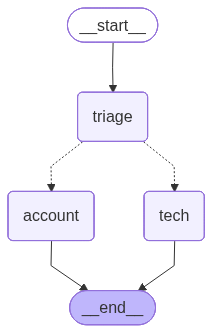

In [25]:
graph = graph_builder.compile()

graph